# 📊 SoGood — Analyse des données (KPI)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

PATH = '../data/processed/products_clean.parquet'
df = pd.read_parquet(PATH)
df.shape

(1387945, 11)

## KPI 1 — Nutri-Score distribution

nutriscore_grade
e                 25.899909
d                 24.056414
c                 19.455109
a                 12.551087
b                 10.067884
not-applicable     7.969597
Name: proportion, dtype: float64


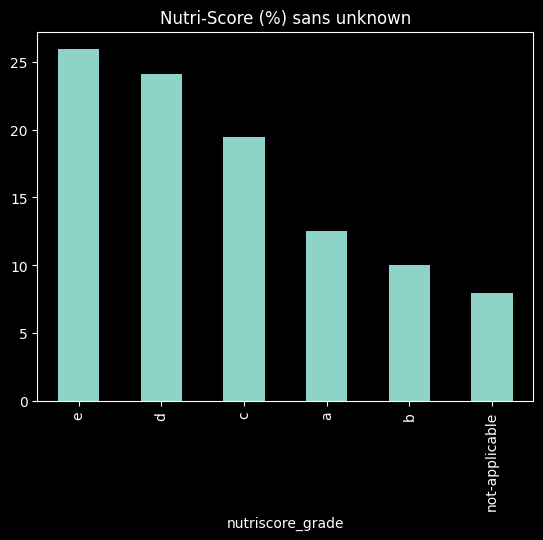

In [14]:
df_filtered = df[df['nutriscore_grade'] != 'unknown']

kpi = df_filtered['nutriscore_grade'].value_counts(normalize=True) * 100
print(kpi)

kpi.plot(kind='bar')
plt.title('Nutri-Score (%) sans unknown')
plt.show()

## KPI 2 — NOVA distribution

In [6]:
kpi_nova = df['nova_group'].value_counts(normalize=True) * 100
print(kpi_nova)

nova_group
4    58.333104
3    20.615861
1    13.050704
2     8.000331
Name: proportion, dtype: float64


## KPI 3 — Produits à risque

In [7]:
high_sugar = (df['sugars'] > df['sugars'].quantile(0.9)).mean() * 100
high_fat = (df['fat'] > df['fat'].quantile(0.9)).mean() * 100
high_salt = (df['salt'] > df['salt'].quantile(0.9)).mean() * 100

print("High sugar %:", high_sugar)
print("High fat %:", high_fat)
print("High salt %:", high_salt)

High sugar %: 0.29417592195656167
High fat %: 0.29835476189618465
High salt %: 0.25267571841823705


## KPI 4 — Top brands

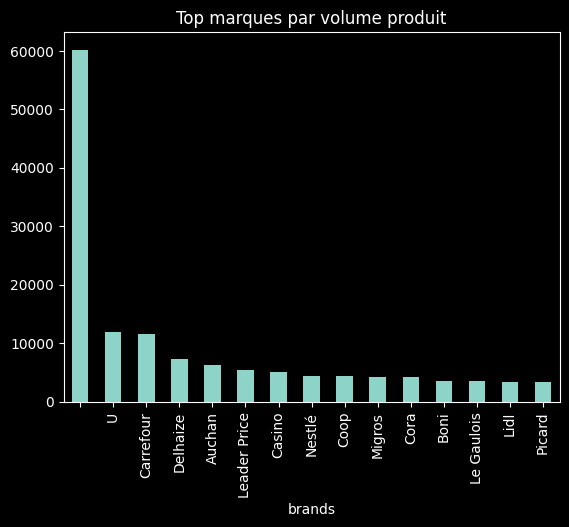

In [9]:
top_brands = df['brands'].value_counts().head(15)

top_brands.plot(kind='bar')
plt.title("Top marques par volume produit")
plt.show()

## KPI 5 — Catégories les plus représentées

In [10]:
top_categories = df['categories'].value_counts().head(15)
top_categories

categories
                                                                                                                                                                                                                           48808
Viandes et dérivés, Viandes, Poulet et dérivés, Volailles, Poulets, Filets de poulet                                                                                                                                        4105
Boissons                                                                                                                                                                                                                    3940
Snacks, Snacks sucrés, Confiseries, Bonbons                                                                                                                                                                                 3177
Viandes et dérivés, Viandes, Charcuteries, Jambons, Jambons blancs                       

## KPI 6 — Produits “controversés”

In [11]:
controversial = df[
    (df['sugars'] > df['sugars'].quantile(0.95)) |
    (df['fat'] > df['fat'].quantile(0.95)) |
    (df['salt'] > df['salt'].quantile(0.95))
]

print("Produits controversés:", len(controversial))

Produits controversés: 5818


## KPI 7 — Qualité des données

In [12]:
missing_rate = df.isnull().mean() * 100
missing_rate.sort_values(ascending=False)

image_url           100.000000
salt                 97.415604
sugars               96.989794
fat                  96.931867
nova_group           71.258155
ingredients_text     60.218020
categories           43.603817
brands               38.950751
nutriscore_grade      0.008646
product_name          0.000000
additives_count       0.000000
dtype: float64